<a href="https://colab.research.google.com/github/MK1250/AI_Mascot_Credit-Card-Default_Prediction/blob/main/Week4_Starter_Notebook_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Week 4 Assignment Starter Notebook
**Battle of the Neural Network Mascots – Credit Default Edition**

📌 **Instructions:**
- Complete your model in accordance with your assigned personality rules.
- Do NOT modify the dataset preparation block.
- Train and validate your model, then report test accuracy.
- Include training vs validation plots and a short reflection.
- Log your AI interactions if you use Deep Learning Buddy.


#  **Description:**
  *Project by: Maria Contreras*

  Chosen Personality: Activation Artist - *Express Yourself*
  
  Activations: tanh; ReLU; Softmax

  Layer Sizes:

In [ ]:
# 🚫 DO NOT MODIFY THIS BLOCK
# Starter Code for Week 4 - Dataset Preparation
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"
df = pd.read_excel(url, header=1)
df.rename(columns={'default payment next month': 'default'}, inplace=True)

# Drop ID column
df = df.drop(columns=["ID"])

# Split features and labels
X = df.drop(columns=["default"]).values
y = df["default"].values

# Split into train (60%), temp (40%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
# Split temp into validation (20%) and test (20%)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

print("Data split complete.")
print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_valid.shape}")
print(f"Test set: {X_test.shape}")

Data split complete.
Training set: (18000, 23)
Validation set: (6000, 23)
Test set: (6000, 23)


## *Step 1: Define the Keras Model*

In [ ]:
# Keras Import
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# keeping weigths the same:
tf.keras.utils.set_random_seed(42)

# define the sequential model
model = Sequential([
    Dense(2, activation = 'tanh', input_shape = (X_train.shape[1],)),
    Dense(8, activation = 'relu'),
    Dense(2, activation = 'softmax')
])

# Compile the model
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## *Step 2: Train the Model*

In [ ]:
history = model.fit(X_train, y_train, epochs = 60, validation_data = (X_valid, y_valid), batch_size = 1000)

Epoch 1/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.4221 - loss: 0.7152 - val_accuracy: 0.4750 - val_loss: 0.6878
Epoch 2/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5131 - loss: 0.6710 - val_accuracy: 0.5717 - val_loss: 0.6498
Epoch 3/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6182 - loss: 0.6353 - val_accuracy: 0.6643 - val_loss: 0.6187
Epoch 4/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6952 - loss: 0.6051 - val_accuracy: 0.7260 - val_loss: 0.5921
Epoch 5/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7513 - loss: 0.5799 - val_accuracy: 0.7765 - val_loss: 0.5713
Epoch 6/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7789 - loss: 0.5606 - val_accuracy: 0.7788 - val_loss: 0.5564
Epoch 7/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7788 - loss: 0.5466 - val_accuracy: 0.7788 - val_loss: 0.5460
Epoch 8/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7788 - loss: 0.5365 - val_accuracy: 0.7788 - val_loss

## *Step 6: Evaluate the Model*

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Testing Accuracy: {accuracy: .2f}")

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8165 - loss: 0.4424
Testing Accuracy:  0.82


In [ ]:
# How many 0 vs 1
preds = model.predict(X_valid).argmax(axis=1)
print(np.bincount(preds))

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[5315  685]


## *Step 7: Visualization of Testing and Valiadation Accuracy*

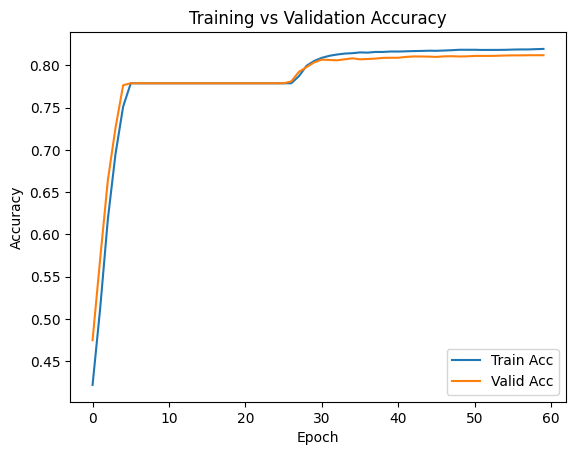

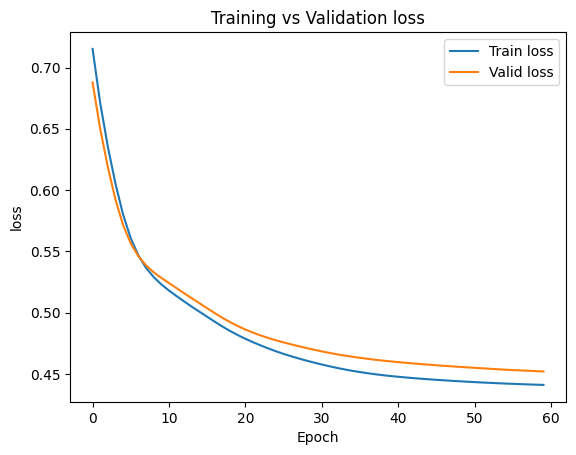

In [ ]:
# Visualization taken from Keras_Titanic_Binary_Classification_Demo.ipynb

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label = 'Train Acc')
plt.plot(history.history['val_accuracy'], label = 'Valid Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label = 'Train loss')
plt.plot(history.history['val_loss'], label = 'Valid loss')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.title('Training vs Validation loss')
plt.legend()
plt.show()



# *Notes*

Run 1

2 tanh, 8 rulu, 1 sigmoid, 20 epochs, training accuracy = 0.82 val acc = 0.81, batchsize 32

Run 2

3, tanh, 8 rulut 1 sigmoid, 30 epochs, training accuracy =


## 📝 Reflection
- What went well?
- What didn’t?
- What would you do differently next time?
- How did your model meet your assigned mascot constraints?